# Recruitment Process Optimisation — People Analytics Case Study

**Author:** Denerson  
**Objective:** Analyse one year of recruitment data to help the Talent Acquisition
team understand process efficiency, identify funnel bottlenecks, and evaluate the
effectiveness of different sourcing channels.

This notebook is structured to mirror the final presentation, so it reads
top-to-bottom as a single narrative.

## Business Questions

1. **Sourcing channel effectiveness** - which channels perform best on *volume* of
   hires and *efficiency* (conversion rate)?
2. **Time to fill** - average time from requisition opened to hire, and how it
   varies by department.
3. **Funnel health** - conversion rates between hiring stages and where the biggest
   drop-offs are.
4. **Recommendations** - top 2–3 actionable improvements for the team.


## Notebook Structure

- **0. Setup & Data Loading** — imports, load raw data, first look.
- **1. Data Preparation** — parse dates, handle data quality issues, reconstruct
  the funnel.
- **2. Sourcing Channels** — volume vs. conversion efficiency.
- **3. Funnel Health** — stage-to-stage conversion and drop-offs.
- **4. Time to Fill** — by department (mean and median).
- **5. Synthesis & Recommendations** — turning findings into actions.


## 0. Setup & Data Loading

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [5]:
import os
print(os.getcwd())


/Users/ddenerson/Documents/Cases/wise-people-analytics-case/notebooks


In [6]:
df = pd.read_csv('../data/raw/applications_data.csv')
df.shape

(1049, 12)

In [7]:
import os
print(os.listdir('.'))

['.ipynb_checkpoints', 'recruitment_funnel_analysis.ipynb']


## 1. Data Preparation

### 1.1 Investigating date coherence
Requisitions open in 2024–2025, but application/hire dates extend into 2026–2027.
Before computing time to fill, we check whether this is a data quality issue.


In [9]:
# Parse date columns explicitly (m/d/Y) so downstream date arithmetic works.
date_cols = ['application_date', 'date_offer_extended',
             'date_hired', 'date_requisition_opened']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')

df[date_cols].dtypes



application_date           datetime64[ns]
date_offer_extended        datetime64[ns]
date_hired                 datetime64[ns]
date_requisition_opened    datetime64[ns]
dtype: object

In [10]:
# Requisitions open in 2024–2025 but some applications land in 2026–2027, which is
# suspicious. We measure the gap between a req opening and the application to see
# whether it's a plausible business pattern or a data quality problem.
df['days_req_to_app'] = (df['application_date'] - df['date_requisition_opened']).dt.days
df['days_req_to_app'].describe()

count    1049.000000
mean      341.768351
std       228.929888
min         7.000000
25%       154.000000
50%       297.000000
75%       502.000000
max       923.000000
Name: days_req_to_app, dtype: float64

In [11]:
# We use 180 days as a sanity check. A gap this long between opening a role and
# getting an application is hard to explain, so we flag these rows to look closer.

implausible = df[df['days_req_to_app'] > 180]
print("Rows with gap > 180 days:", len(implausible), f"({len(implausible)/len(df):.0%})")
print("\nMax gap (days):", df['days_req_to_app'].max())


Rows with gap > 180 days: 741 (71%)

Max gap (days): 923


In [16]:
# If the anomaly were real, we'd expect it to cluster somewhere (a slow department,
# a hard-to-fill role). If it's spread evenly, that points to systematic noise
# rather than a genuine signal.
print("By department:")
print(implausible['department'].value_counts(normalize=True).round(2))
print("\nOutcome breakdown:")
print(implausible['current_stage'].value_counts().head())



By department:
department
Sales         0.29
Technology    0.26
Marketing     0.11
Operations    0.11
Finance       0.11
HR            0.11
Name: proportion, dtype: float64

Outcome breakdown:
current_stage
Rejected                    430
Hired                       226
Hiring Manager Interview     25
Applied                      17
Technical Assessment         14
Name: count, dtype: int64


### Decision: time-to-fill metric

71% of applications arrive more than 180 days after the requisition opens
(max 923), and this is spread evenly across departments. This points to a data
artifact, not a real pattern. Filtering would remove most of the data, so we keep
the official metric (`requisition_opened → hired`) with a caveat, and we also add
`application → hired` as the measure the team actually controls and can act on.




In [12]:
# Official metric, kept as asked but skewed by the sourcing-gap artifact.
df['time_to_fill'] = (df['date_hired'] - df['date_requisition_opened']).dt.days

# The part TA actually controls: screening + interviews - the clean signal.
df['time_to_hire'] = (df['date_hired'] - df['application_date']).dt.days

df[['time_to_fill', 'time_to_hire']].describe()



,time_to_fill,time_to_hire
count,295.000000,295.000000
mean,428.508475,39.630508
std,237.091731,1.678926
min,61.000000,33.000000
25%,230.000000,39.000000
50%,412.000000,39.000000
75%,596.500000,40.000000
max,962.000000,48.000000


## 2. Sourcing Channels → Slide 2

We compare each channel on two things: volume (how many hires it brings) and
efficiency (what share of its applicants get hired). A channel can be strong on
one and weak on the other, so we look at both together.



In [23]:
# Applications, hires, and hire rate per channel.
by_source = df.groupby('source').agg(
    applications=('application_id', 'count'),
    hires=('current_stage', lambda s: (s == 'Hired').sum())
)
by_source['hire_rate_%'] = (by_source['hires'] /
                            by_source['applications'] * 100).round(1)
by_source = by_source.sort_values('applications', ascending=False)
by_source



,applications,hires,hire_rate_%
source,,,
LinkedIn,701,233,33.2
Careers Site,166,8,4.8
Agency,67,0,0.0
Employee Referral,61,54,88.5
Indeed,33,0,0.0
University Job Board,21,0,0.0


## 3. Funnel Health → Slide 3

We measure how many candidates move from one stage to the next.

`current_stage` shows the furthest stage a candidate reached. Rejected and Withdrew
are outcomes, not stages, so those 582 candidates cannot be placed in a specific
step. We build the funnel from the 467 candidates with a known stage, using total
applications as the top of the funnel.


In [13]:
# Funnel stages in process order.
stages = ['Applied', 'HR Screen', 'Hiring Manager Interview',
          'Technical Assessment', 'Final Interview', 'Offer Extended', 'Hired']

rank = {s: i for i, s in enumerate(stages)}

# Keep only candidates whose current_stage is a real stage (not Rejected/Withdrew).
known = df[df['current_stage'].isin(stages)].copy()
known['stage_rank'] = known['current_stage'].map(rank)

# Cumulative count: a candidate at a later stage also passed all earlier ones.
funnel = {'Applied': len(df)}
for i, s in enumerate(stages):
    if s != 'Applied':
        funnel[s] = int((known['stage_rank'] >= i).sum())

funnel_df = pd.DataFrame({'stage': stages,
                          'candidates': [funnel[s] for s in stages]})
funnel_df['conversion_%'] = (funnel_df['candidates'] /
                             funnel_df['candidates'].shift(1) * 100).round(1)
funnel_df



,stage,candidates,conversion_%
0,Applied,1049,NaN
1,HR Screen,431,41.1
2,Hiring Manager Interview,398,92.3
3,Technical Assessment,343,86.2
4,Final Interview,321,93.6
5,Offer Extended,298,92.8
6,Hired,295,99.0


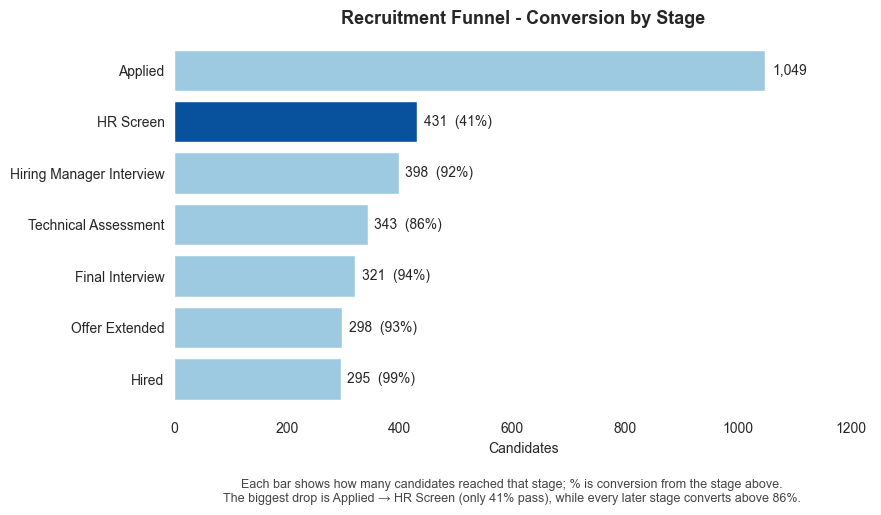

In [22]:
# 'white' style removes the background grid for a cleaner slide look.
sns.set_style('white')

fig, ax = plt.subplots(figsize=(9, 5.5))

# Highlight HR Screen, where the biggest drop happens.
colors = ['#9ecae1'] * len(funnel_df)
colors[1] = '#08519c'

ax.barh(funnel_df['stage'], funnel_df['candidates'], color=colors)
ax.invert_yaxis()  # Applied stays on top

# Show count and conversion % next to each bar.
for i, (count, conv) in enumerate(zip(funnel_df['candidates'],
                                      funnel_df['conversion_%'])):
    label = f"{count:,}"
    if not pd.isna(conv):
        label += f"  ({conv:.0f}%)"
    ax.text(count + 12, i, label, va='center', fontsize=10)

ax.set_xlabel('Candidates')
ax.set_title('Recruitment Funnel - Conversion by Stage',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, funnel_df['candidates'].max() * 1.18)
ax.tick_params(axis='x', length=0)
sns.despine(left=True, bottom=True)

# Centered caption so the chart explains itself on the slide.
caption = ("Each bar shows how many candidates reached that stage; "
           "% is conversion from the stage above.\n"
           "The biggest drop is Applied → HR Screen (only 41% pass), "
           "while every later stage converts above 86%.")
fig.subplots_adjust(bottom=0.18)
fig.text(0.5, 0.02, caption, ha='center', va='bottom', fontsize=9, color='#444444')

plt.savefig('../outputs/figures/funnel.png', dpi=120, bbox_inches='tight')
plt.show()

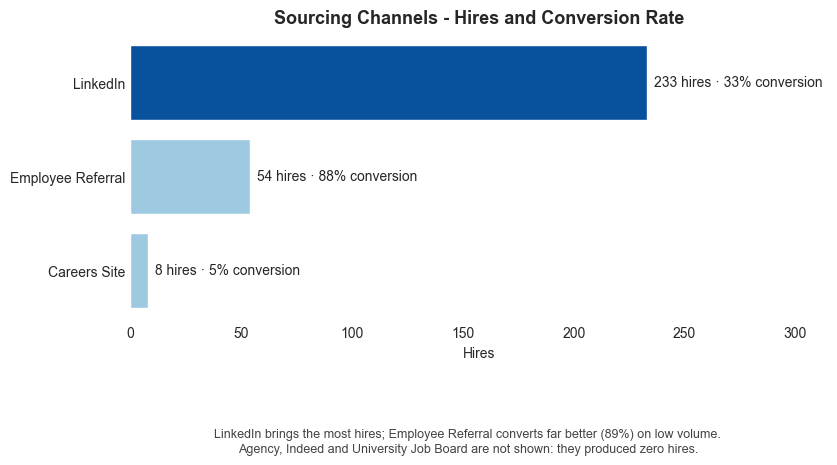

In [24]:
# Keep only channels that produced hires; the empty ones become a caption note.
active = by_source[by_source['hires'] > 0].sort_values('hires', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#9ecae1'] * len(active)
colors[-1] = '#08519c'  # top by hires = LinkedIn
ax.barh(active.index, active['hires'], color=colors)

# Each bar shows hires and conversion rate together.
for i, (h, rate) in enumerate(zip(active['hires'], active['hire_rate_%'])):
    ax.text(h + 3, i, f"{h} hires · {rate:.0f}% conversion", va='center', fontsize=10)

ax.set_xlabel('Hires')
ax.set_title('Sourcing Channels - Hires and Conversion Rate',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, active['hires'].max() * 1.35)
ax.tick_params(length=0)
sns.despine(left=True, bottom=True)

# Reserve space below, then place the caption low and centered.
fig.subplots_adjust(bottom=0.30)
caption = ("LinkedIn brings the most hires; Employee Referral converts far better "
           "(89%) on low volume.\n"
           "Agency, Indeed and University Job Board are not shown: they produced "
           "zero hires.")
fig.text(0.5, 0.06, caption, ha='center', va='center', fontsize=9, color='#444444')

plt.savefig('../outputs/figures/channels.png', dpi=120, bbox_inches='tight')
plt.show()



## 4. Time to Fill → Slide 4

The case asks for time to fill (from requisition opened to hire) by department.
As we saw in Section 1, this metric is distorted by the date problem. So we show
it with a caveat and focus on time to hire (from application to hire), which is
the part the team controls.




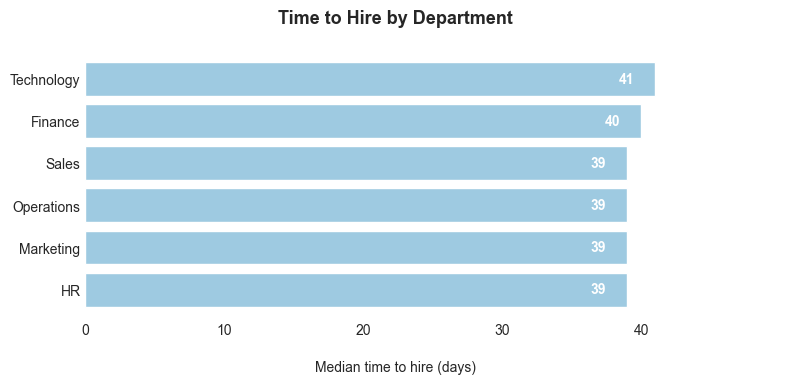

In [30]:
# Plot the clean metric: median time to hire per department.
tth = hired.groupby('department')['time_to_hire'].median().sort_values()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(tth.index, tth.values, color='#9ecae1', zorder=3)

# Labels inside the bars.
for i, v in enumerate(tth.values):
    ax.text(v - 1.5, i, f"{v:.0f}", va='center', ha='right',
            fontsize=10, color='white', fontweight='bold', zorder=4)

ax.set_xlim(0, 50)
ax.set_xticks([0, 10, 20, 30, 40])
ax.tick_params(length=0)
sns.despine(left=True, bottom=True)

# Figure-level title and x-label, centered across the whole figure.
fig.suptitle('Time to Hire by Department', fontsize=13, fontweight='bold', y=0.98)
fig.supxlabel('Median time to hire (days)', fontsize=10, y=0.02)

plt.tight_layout()
plt.savefig('../outputs/figures/time_to_hire.png', dpi=120)
plt.show()



## 5. Synthesis & Recommendations → Slides 1 & 5

This section pulls together the key numbers behind the recommendations. Each number
comes from the sections above, so every claim on the slides is traceable.



In [31]:
# Key numbers that support the recommendations, pulled from the analysis above.
dead = by_source[by_source['hires'] == 0]
dead_apps = int(dead['applications'].sum())

referral_rate = by_source.loc['Employee Referral', 'hire_rate_%']
linkedin_rate = by_source.loc['LinkedIn', 'hire_rate_%']
referral_multiplier = round(referral_rate / linkedin_rate, 1)

print("Dead channels:", list(dead.index), "->", dead_apps, "applications, 0 hires")
print(f"Referral converts {referral_multiplier}x better than LinkedIn "
      f"({referral_rate:.0f}% vs {linkedin_rate:.0f}%)")
print(f"HR Screen drop: {100 - funnel_df.loc[1, 'conversion_%']:.0f}% "
      f"of applicants don't pass the first screen")
print(f"Candidates without a recorded stage: {len(df) - len(known)} "
      f"({(len(df) - len(known)) / len(df) * 100:.0f}%)")


Dead channels: ['Agency', 'Indeed', 'University Job Board'] -> 121 applications, 0 hires
Referral converts 2.7x better than LinkedIn (88% vs 33%)
HR Screen drop: 59% of applicants don't pass the first screen
Candidates without a recorded stage: 582 (55%)


In [32]:
# Where in the funnel the losses happen. The first screen is by far the biggest.
total_lost = len(df) - funnel_df.loc[funnel_df['stage'] == 'Hired', 'candidates'].iloc[0]
lost_at_screen = len(df) - funnel_df.loc[funnel_df['stage'] == 'HR Screen', 'candidates'].iloc[0]
screen_share = lost_at_screen / total_lost * 100

print(f"Total lost (Applied to Hired): {total_lost}")
print(f"Lost at the first screen: {lost_at_screen}")
print(f"Share of all losses at the first screen: {screen_share:.0f}%")


Total lost (Applied to Hired): 754
Lost at the first screen: 618
Share of all losses at the first screen: 82%


### The story

The interview process works. Once a candidate passes the first screen, the funnel
converts above 86% and hiring takes about 40 days, uniform across departments. The
problem is not speed. It is the entrance: which channels bring people, how the first
screen handles them, and whether we can even measure it.

### Recommendations

**1. Reallocate sourcing effort.**
Three channels (Agency, Indeed, University Job Board) took 121 applications and made
zero hires, while Employee Referral converts 2.7x better than LinkedIn but is only
6% of volume. Move effort from the channels that produce nothing into a structured
referral program.

**2. Fix the top-of-funnel blind spot.**
59% of applicants drop at the first screen, and this is also the least visible part
of the process: 55% of candidates have no recorded stage. Audit the HR Screen
criteria and start recording each candidate's exit stage, so the biggest point of
loss can finally be measured.

**3. Track a metric you can trust.**
Official time to fill is distorted by a data artifact (applications dated long after
the requisition opens). Adopt time to hire as the working metric, and investigate
why the gap between opening a role and receiving applications is so large.

### The principle

The gains are not in going faster. They are in fixing what happens before the first
human review: better channels, sharper screening, and a funnel the team can actually
see and measure.